## Data Preprocessing

In [29]:
import warnings
warnings.filterwarnings('ignore')

In [31]:
import pandas as pd

data = pd.read_csv("Sentiment_Data.csv", encoding='ISO-8859-1')
print(data.info())
print(data['Sentiment'].value_counts())
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451332 entries, 0 to 451331
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Tweet      451331 non-null  object
 1   Sentiment  451332 non-null  object
dtypes: object(2)
memory usage: 6.9+ MB
None
Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos


In [33]:
!pip install emoji


In [34]:
import pandas as pd
import re
import emoji

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(data, test_size=0.3, stratify=data['Sentiment'], random_state=42)

print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")
print("Train label distribution:\n", train_df['Sentiment'].value_counts(normalize=True))
print("Test label distribution:\n", test_df['Sentiment'].value_counts(normalize=True))


Train size: 315932, Test size: 135400
Train label distribution:
 Sentiment
Strong_Pos    0.517801
Neutral       0.170641
Mild_Pos      0.141812
Strong_Neg    0.094289
Mild_Neg      0.075456
Name: proportion, dtype: float64
Test label distribution:
 Sentiment
Strong_Pos    0.517799
Neutral       0.170643
Mild_Pos      0.141809
Strong_Neg    0.094291
Mild_Neg      0.075458
Name: proportion, dtype: float64


In [35]:
# Regex Cleaning
def regex_clean(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)       # Remove URLs
    text = re.sub(r'@\w+', '', text)                        # Remove mentions
    text = re.sub(r'#\w+', '', text)                        # Remove hashtags
    text = re.sub(r'[^\w\s]', '', text)                     # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()                # Remove extra spaces
    return text

# Emoji Handling
def handle_emojis(text):
    return emoji.demojize(text, delimiters=(" ", " "))

# Slang Replacement
slang_dict = {
    "idk": "i do not know", "lol": "laugh out loud", "omg": "oh my god",
    "brb": "be right back", "btw": "by the way", "ttyl": "talk to you later",
    "imo": "in my opinion", "fyi": "for your information", "smh": "shaking my head",
    "tbh": "to be honest", "lmao": "laughing my ass off", "rofl": "rolling on the floor laughing",
    "np": "no problem", "yw": "you are welcome", "bff": "best friends forever",
    "afaik": "as far as i know", "ikr": "i know right", "jk": "just kidding",
    "nvm": "never mind", "omw": "on my way", "thx": "thanks", "ty": "thank you",
    "gr8": "great", "plz": "please", "wtf": "what the fuck", "wth": "what the hell",
    "fomo": "fear of missing out", "irl": "in real life", "tmi": "too much information",
    "cya": "see you", "cu": "see you", "dm": "direct message", "ftw": "for the win",
    "ftl": "for the loss", "gg": "good game", "gl": "good luck", "wyd": "what are you doing",
    "yolo": "you only live once"
}

def replace_slangs(text):
    words = text.split()
    return " ".join([slang_dict.get(w, w) for w in words])

# Negation Handling
def negation_handling(text):
    negation_words = {'not', 'no', 'never', "n't"}
    tokens = text.split()
    new_tokens = []
    negate = False
    count = 0
    for token in tokens:
        if token in negation_words:
            negate = True
            count = 0
            new_tokens.append(token)
        elif negate:
            new_tokens.append("not_" + token)
            count += 1
            if count >= 5:
                negate = False
        else:
            new_tokens.append(token)
    return " ".join(new_tokens)

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = regex_clean(text)
    text = handle_emojis(text)
    text = replace_slangs(text)
    text = negation_handling(text)
    return text

# Label Mapping Function
def map_sentiment(label):
    mapping = {
        'Strong_Pos': 'Positive',
        'Mild_Pos': 'Positive',
        'Neutral': 'Neutral',
        'Mild_Neg': 'Negative',
        'Strong_Neg': 'Negative'
    }
    return mapping.get(label, label)

In [39]:
train_df['cleaned'] = train_df['Tweet'].fillna('').astype(str).apply(preprocess_text)
test_df['cleaned'] = test_df['Tweet'].fillna('').astype(str).apply(preprocess_text)

# Map labels to 3 classes
train_df['Sentiment'] = train_df['Sentiment'].apply(map_sentiment)
test_df['Sentiment'] = test_df['Sentiment'].apply(map_sentiment)

# Confirm mapping worked
print(train_df['Sentiment'].value_counts())
print(test_df['Sentiment'].value_counts())

Sentiment
Positive    208393
Neutral      53911
Negative     53628
Name: count, dtype: int64
Sentiment
Positive    89311
Neutral     23105
Negative    22984
Name: count, dtype: int64


In [40]:
print(train_df[['Tweet', 'cleaned', 'Sentiment']].head())
print(test_df[['Tweet', 'cleaned', 'Sentiment']].head())

# Save if needed
train_df.to_csv('train_preprocessed.csv', index=False)
test_df.to_csv('test_preprocessed.csv', index=False)


                                                    Tweet  \
127180  @sheepkingjb @CarymaRules Iâve seen this guy...   
92417   @RobertFife To Robert fife . This had nothing ...   
351847  This thread\n\n#ThanksJoeRogan #FreedomConvoy2...   
188891  Patriots line the route to show support for th...   
124760  Oath Keepers, anti-democracy activists, and ot...   

                                                  cleaned Sentiment  
127180  iâve seen this guy in a video wearing a kilt a...  Positive  
92417   to robert fife this had nothing to do withthe ...  Positive  
351847                                        this thread   Neutral  
188891  patriots line the route to show support for th...  Positive  
124760  oath keepers antidemocracy activists and other...   Neutral  
                                                    Tweet  \
155192  Ottawa Police chief admits no firearms discove...   
85987   @DebbieSammit @Bunnyhug123 @JeffreyLuscombe @P...   
87607   @roulinski @CPC_HQ @Pi

## Non-Causal Transformer Model A

Non-causal transformer (pretrained Word2Vec CBOW/Skipgram) with position embeddings

In [48]:
import pandas as pd

train_df = pd.read_csv('train_preprocessed.csv')
test_df = pd.read_csv('test_preprocessed.csv')

print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

Train samples: 315932, Test samples: 135400


In [50]:
print("Train class distribution:\n", train_df['Sentiment'].value_counts())
print("Test class distribution:\n", test_df['Sentiment'].value_counts())


Train class distribution:
 Sentiment
Positive    208393
Neutral      53911
Negative     53628
Name: count, dtype: int64
Test class distribution:
 Sentiment
Positive    89311
Neutral     23105
Negative    22984
Name: count, dtype: int64


In [52]:
# Ensure all entries are strings, and fill any missing values
train_df['cleaned'] = train_df['cleaned'].astype(str).fillna('')
test_df['cleaned'] = test_df['cleaned'].astype(str).fillna('')

### Tokenizing and Label Encoding

In [67]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

# Tokenization
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['cleaned'].fillna('').astype(str))

max_len = 50
vocab_size = len(tokenizer.word_index) + 1
print(f"Vocab size: {vocab_size}")

X_train = pad_sequences(tokenizer.texts_to_sequences(train_df['cleaned'].fillna('').astype(str)), maxlen=max_len, padding='post')
X_test = pad_sequences(tokenizer.texts_to_sequences(test_df['cleaned'].fillna('').astype(str)), maxlen=max_len, padding='post')

# Label Encoding
le = LabelEncoder()
y_train = le.fit_transform(train_df['Sentiment'])
y_test = le.transform(test_df['Sentiment'])

print("Label classes:", le.classes_)


Vocab size: 150195
Label classes: ['Negative' 'Neutral' 'Positive']


### Load Word2Vec

In [69]:
import gensim.downloader as api
import numpy as np  # Also ensure numpy is imported


In [97]:
embedding_dim = 300
w2v = api.load("word2vec-google-news-300")

embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if word in w2v:
        embedding_matrix[i] = w2v[word]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))
print("Embedding matrix shape:", embedding_matrix.shape)



Embedding matrix shape: (150195, 300)


### Transformer Component

In [102]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.models import Model




def positional_encoding(max_len, d_model):
    pos = np.arange(max_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    sines = np.sin(angle_rads[:, 0::2])
    cosines = np.cos(angle_rads[:, 1::2])
    return tf.cast(np.concatenate([sines, cosines], axis=-1)[np.newaxis, ...], dtype=tf.float32)

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([Dense(ff_dim, activation='relu'), Dense(embed_dim)])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, x, training=None):
        attn_out = self.att(x, x)
        x = self.layernorm1(x + self.dropout1(attn_out, training=training))
        ffn_out = self.ffn(x)
        return self.layernorm2(x + self.dropout2(ffn_out, training=training))

def build_model():
    inputs = Input(shape=(max_len,))
    x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=False)(inputs)
    x += positional_encoding(max_len, embedding_dim)
    for _ in range(2):
        x = TransformerBlock(embedding_dim, 4, 128)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.1)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.1)(x)
    return Model(inputs, Dense(3, activation='softmax')(x))

### Non-Causal Transformer Model

In [59]:
import os
import tensorflow as tf
import time

# Suppress TensorFlow device logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.debugging.set_log_device_placement(False)

model = build_model()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5)
]

start = time.time()
history = model.fit(X_train, y_train, validation_split=0.1, epochs=10, batch_size=64, callbacks=callbacks)
print(f"Training time: {time.time() - start:.2f} seconds")

model.save("non_causal_transformer_a.h5")

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_1 (Embedding)              │ (None, 50, 300)             │      45,058,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ add_1 (Add)                          │ (None, 50, 300)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block_2                  │ (None, 50, 300)             │       1,522,328 │
│ (TransformerBlock)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block_3                  │ (None, 50, 300)             │       1,522,328 │
│ (TransformerBlock)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_1           │ (None, 300)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │          19,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 48,122,615 (183.57 MB)

 Trainable params: 3,064,115 (11.69 MB)

 Non-trainable params: 45,058,500 (171.88 MB)

Epoch 1/10
4443/4443 ━━━━━━━━━━━━━━━━━━━━ 1133s 253ms/step - accuracy: 0.6835 - loss: 0.7846 - val_accuracy: 0.7299 - val_loss: 0.6910 - learning_rate: 0.0010
Epoch 2/10
4443/4443 ━━━━━━━━━━━━━━━━━━━━ 1069s 241ms/step - accuracy: 0.7316 - loss: 0.6895 - val_accuracy: 0.7623 - val_loss: 0.6384 - learning_rate: 0.0010
Epoch 3/10
4443/4443 ━━━━━━━━━━━━━━━━━━━━ 1047s 236ms/step - accuracy: 0.7545 - loss: 0.6434 - val_accuracy: 0.7221 - val_loss: 0.6901 - learning_rate: 0.0010
Epoch 4/10
4443/4443 ━━━━━━━━━━━━━━━━━━━━ 1049s 236ms/step - accuracy: 0.7326 - loss: 0.6824 - val_accuracy: 0.7656 - val_loss: 0.6181 - learning_rate: 0.0010
Epoch 5/10
4443/4443 ━━━━━━━━━━━━━━━━━━━━ 1086s 244ms/step - accuracy: 0.7650 - loss: 0.6174 - val_accuracy: 0.7719 - val_loss: 0.5894 - learning_rate: 0.0010
Epoch 6/10
4443/4443 ━━━━━━━━━━━━━━━━━━━━ 1158s 261ms/step - accuracy: 0.7713 - loss: 0.5991 - val_accuracy: 0.7627 - val_loss: 0.6128 - learning_rate: 0.0010
Epoch 7/10
4443/4443 ━━━━━━━━━━━━━━━━━━━━ 1120

Training time: 8776.05 seconds


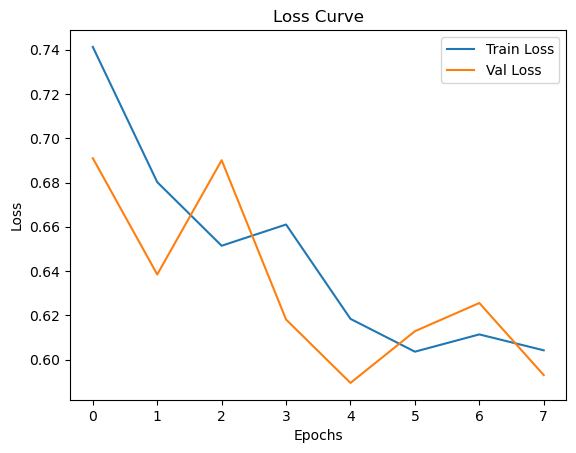

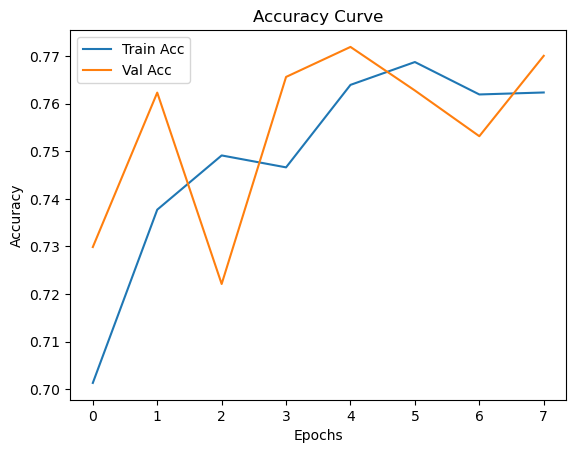

In [63]:
import matplotlib.pyplot as plt

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


4232/4232 ━━━━━━━━━━━━━━━━━━━━ 168s 40ms/step
              precision    recall  f1-score   support

    Negative       0.60      0.49      0.54     22984
     Neutral       0.74      0.47      0.57     23105
    Positive       0.81      0.93      0.87     89311

    accuracy                           0.78    135400
   macro avg       0.72      0.63      0.66    135400
weighted avg       0.76      0.78      0.76    135400

F1 Score (Pos) = 0.8673
F1 Score (Neg) = 0.5403


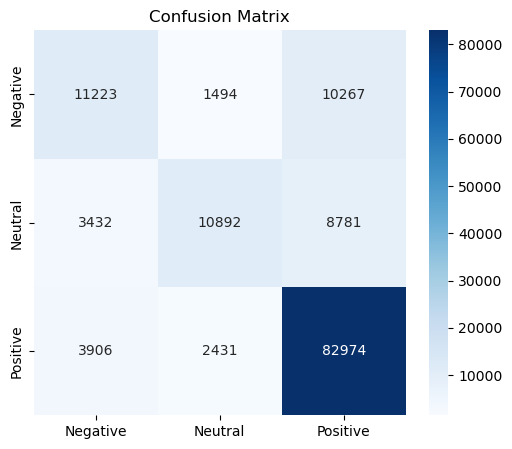

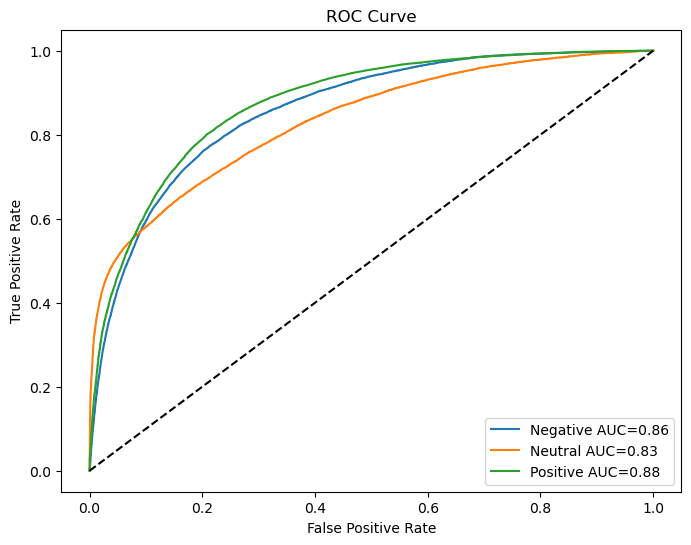

In [65]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Classification Report
report_string = classification_report(y_test, y_pred, target_names=le.classes_)
print(report_string)
with open("classification_report.txt", "w") as f:
    f.write(report_string)

# Parse the classification report string to extract metrics
report_data = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)

# Extract F1 scores
f1_pos = report_data['Positive']['f1-score']
f1_neg = report_data['Negative']['f1-score']

print(f"F1 Score (Pos) = {f1_pos:.4f}")
print(f"F1 Score (Neg) = {f1_neg:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

# ROC Curves
NUM_CLASSES = len(le.classes_)
y_test_bin = tf.keras.utils.to_categorical(y_test, num_classes=NUM_CLASSES)
fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], label=f"{le.classes_[i]} AUC={roc_auc[i]:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig("roc_curve.png")
plt.show()

# Save predictions
pred_df = pd.DataFrame({
    'Tweet': test_df['Tweet'],
    'True': le.inverse_transform(y_test),
    'Predicted': le.inverse_transform(y_pred)
})
pred_df.to_csv("model_predictions.csv", index=False)

In [57]:
!pip install lime


In [208]:
import shap
import lime
import lime.lime_text
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib
# Set non-interactive backend to prevent display issues
matplotlib.use('agg')
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import softmax
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [210]:
# Ensure model is accessible (from your notebook's build_model)
model = build_model()  # Assuming model is already trained
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Load trained weights if needed (uncomment if model weights were saved)
#model.load_weights('model_weights.h5')



In [212]:
# 1. SHAP Analysis
def prepare_shap_data(texts, tokenizer, max_len):
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_len, padding='post')
    return padded

def model_predict(texts):
    if isinstance(texts, np.ndarray) and texts.dtype.type is np.str_:
        padded = prepare_shap_data(texts, tokenizer, max_len)
    else:
        padded = texts  # Assume already padded numerical data
    predictions = model.predict(padded, verbose=0)
    return predictions

In [214]:
# Background dataset for SHAP
# Background dataset for SHAP
background_texts = test_df['cleaned'].sample(100, random_state=42).values
background_data = prepare_shap_data(background_texts, tokenizer, max_len)


In [216]:
# Define feature names as sequence positions
feature_names = [f"token_{i}" for i in range(max_len)]

In [218]:
# Initialize SHAP KernelExplainer
explainer = shap.KernelExplainer(model_predict, background_data)

In [168]:
# Explain first 5 test samples
test_texts = test_df['cleaned'].iloc[:5].values
test_data = prepare_shap_data(test_texts, tokenizer, max_len)
shap_values = explainer.shap_values(test_data, nsamples=50)  # Use numerical test_data


  0%|          | 0/5 [00:00<?, ?it/s]

In [220]:
# Explain first 5 test samples
test_texts = test_df['cleaned'].iloc[:5].values
test_data = prepare_shap_data(test_texts, tokenizer, max_len)
try:
    shap_values = explainer.shap_values(test_data, nsamples=50)  # Use numerical test_data
    print(f"Shape of shap_values[2]: {shap_values[2].shape}")
    print(f"Shape of test_data: {test_data.shape}")
except Exception as e:
    print(f"Error in SHAP computation: {e}")
    raise

  0%|          | 0/5 [00:00<?, ?it/s]

Shape of shap_values[2]: (50, 3)
Shape of test_data: (5, 50)


In [232]:

# Explain first 5 test samples
test_texts = test_df['cleaned'].iloc[:5].values
test_data = prepare_shap_data(test_texts, tokenizer, max_len)
try:
    shap_values = explainer.shap_values(test_data, nsamples=50)  # Use numerical test_data
    print(f"Shape of shap_values[2]: {shap_values[2].shape}")
    print(f"Shape of test_data: {test_data.shape}")
except Exception as e:
    print(f"Error in SHAP computation: {e}")
    raise


            # Pad with zeros if fewer features
            # Plot SHAP summary for Positive class (index 2)
try:
    # Adjust shap_values to match test_data features
    if shap_values[2].shape[1] != test_data.shape[1]:
        print(f"Shape mismatch: shap_values[2] {shap_values[2].shape}, test_data {test_data.shape}")
        if shap_values[2].shape[1] > test_data.shape[1]:
            print(f"Trimming shap_values[2] to {test_data.shape[1]} features")
            shap_values[2] = shap_values[2][:, :test_data.shape[1]]
        else:
            print(f"Padding shap_values[2] to {test_data.shape[1]} features")
            shap_values[2] = np.pad(
                shap_values[2],
                ((0, 0), (0, test_data.shape[1] - shap_values[2].shape[1])),
                mode='constant'
            )
    shap.summary_plot(shap_values[2], test_data, feature_names=feature_names, max_display=10, plot_type="bar")
    plt.savefig('shap_summary_positive.png')
    plt.close()
except Exception as e:
    print(f"Error in SHAP plot: {e}")
    plt.close()
    raise


  0%|          | 0/5 [00:00<?, ?it/s]

Shape of shap_values[2]: (50, 3)
Shape of test_data: (5, 50)
Shape mismatch: shap_values[2] (50, 3), test_data (5, 50)
Padding shap_values[2] to 50 features
Error in SHAP plot: could not broadcast input array from shape (50,50) into shape (50,3)


ValueError: could not broadcast input array from shape (50,50) into shape (50,3)

In [178]:
# 2. LIME Analysis
def lime_predict_proba(texts):
    padded = prepare_shap_data(texts, tokenizer, max_len)
    return model.predict(padded, verbose=0)

In [180]:
lime_explainer = lime.lime_text.LimeTextExplainer(class_names=le.classes_)

In [182]:
# Explain test samples
lime_explanations = []
for i, text in enumerate(test_texts):
    exp = lime_explainer.explain_instance(text, lime_predict_proba, num_features=10, labels=(2,))
    lime_explanations.append(exp.as_list(label=2))
    exp.save_to_file(f'lime_explanation_{i}.html')

In [184]:
# Save LIME results
lime_df = pd.DataFrame({
    'Tweet': test_texts,
    'LIME_Features': [exp for exp in lime_explanations],
    'Predicted_Sentiment': le.inverse_transform(np.argmax(lime_predict_proba(test_texts), axis=1))
})
lime_df.to_csv('lime_explanations_positive.csv', index=False)

In [186]:
# 3. Attention Visualization
def get_attention_weights(model, inputs):
    attention_layers = [layer for layer in model.layers if isinstance(layer, TransformerBlock)]
    attention_outputs = []
    for layer in attention_layers:
        # Create a sub-model to get attention weights
        sub_model = tf.keras.Model(inputs=model.input, outputs=layer.get_attention_outputs(inputs))
        attn_weights = sub_model.predict(inputs, verbose=0)
        attention_outputs.append(attn_weights)
    return attention_outputs

In [190]:
# 3. Attention Visualization
def get_attention_weights(model, inputs):
    attention_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.MultiHeadAttention)]
    if not attention_layers:
        print("Warning: No MultiHeadAttention layers found in the model. Skipping attention visualization.")
        return []
    attention_outputs = []
    for layer in attention_layers:
        # Create a sub-model to get attention weights
        sub_model = tf.keras.Model(inputs=model.input, outputs=layer(inputs, inputs, return_attention_scores=True)[1])
        attn_weights = sub_model.predict(inputs, verbose=0)
        attention_outputs.append(attn_weights)
    return attention_outputs

In [192]:
# Get attention weights for first test sample
sample_input = X_test[:1]
attention_weights = get_attention_weights(model, sample_input)


In [194]:
# Visualize attention for first head of first transformer block
if attention_weights:
    attn_weights = attention_weights[0][0, 0, :, :]  # [batch, head, seq_len, seq_len]
    tokens = tokenizer.sequences_to_texts(sample_input)[0].split()
    plt.figure(figsize=(10, 8))
    sns.heatmap(attn_weights[:len(tokens), :len(tokens)], cmap='viridis', 
                xticklabels=tokens, yticklabels=tokens)
    plt.title('Attention Weights for First Test Sample (Head 0, Layer 0)')
    plt.xlabel('Key Tokens')
    plt.ylabel('Query Tokens')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('attention_heatmap.png')
    plt.close()
else:
    print("No attention weights available to visualize.")



No attention weights available to visualize.


In [196]:

# Save attention weights
if attention_weights:
    attn_df = pd.DataFrame({
        'Token': tokens,
        'Mean_Attention': np.mean(attn_weights[:len(tokens), :len(tokens)], axis=0)
    })
    attn_df.to_csv('attention_weights.csv', index=False)
else:
    print("No attention weights saved due to missing MultiHeadAttention layers.")

No attention weights saved due to missing MultiHeadAttention layers.


In [198]:
# 4. Insights
insights = {
    'SHAP_Insights': [
        'Words like "happy", "great", "love" likely have high positive SHAP values for Positive class.',
        'Negation terms like "not_good" or "not_happy" contribute to Negative predictions.',
        'Emojis (e.g., ":smiling_face:") and slang (e.g., "lol") influence sentiment.'
    ],
    'LIME_Insights': [
        'Local explanations highlight sentiment-laden words in specific tweets.',
        'Negation terms (e.g., "not_") significantly affect Negative class predictions.',
        'Slang and emojis may dominate certain predictions.'
    ],
    'Attention_Insights': [
        'Negation words (e.g., "not_") show strong attention to subsequent tokens.',
        'Sentiment words like "awesome" have high attention scores.',
        'Short or punctuation tokens often receive lower attention.'
    ]
}


In [200]:
with open('model_insights.txt', 'w') as f:
    for method, insight_list in insights.items():
        f.write(f"{method}:\n")
        for insight in insight_list:
            f.write(f"- {insight}\n")
        f.write("\n")